<a href="https://colab.research.google.com/github/tedeliott/multi_opti_for_GoldNPs/blob/main/research_project_round_3_chip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi optimization for gold nanoparticles

## 1. Dataset

import raw dataset

In [1]:
import pandas as pd
import numpy as np

data = [
    # Sample_ID, inner_index, Date, HAuCl4_mM, PVP_mg_ml, AA_mM, Citrate_mM, pH,
    # Au_flow_rate, reducing_agent_flow_rate_mL_h, Z_Average_nm, PDI, Zeta_mV, note

    ["AuNP_001", "A", "07/07/2026", 1, 10, 20, 0,   3, 30, 30, 118.7,  0.1187, -5.33433,  "raw data"],
    ["AuNP_002", "B", "07/07/2026", 1, 10, 20, 0,  11, 30, 30, 60.93,  0.9589, -3.77667,  "raw data"],
    ["AuNP_003", "C", "07/07/2026", 1, 0,  20, 0,   3, 30, 30, 67.94,  0.2034, -18.96,    "raw data"],
    ["AuNP_004", "D", "07/07/2026", 1, 0,  20, 0,  11, 30, 30, 40.38,  0.4956, -30.5333,  "raw data"],
    ["AuNP_005", "E", "07/07/2026", 1, 5,  20, 0,   3, 30, 30, 119.8,  0.1232, -5.98233,  "raw data"],
    ["AuNP_006", "F", "07/07/2026", 1, 5,  20, 5,   3, 30, 30, 104.4,  0.1955, -5.02267,  "raw data"],
    ["AuNP_007", "G", "07/07/2026", 1, 5,  20, 0.5, 3, 30, 30, 120.5,  0.1305, -6.61533,  "raw data"],
    ["AuNP_008", "A", "08/07/2026", 1, 0, 20, 2, 3, 30, 30, 118.7,  0.2260, -20.16667, "AI model round 1"],

    ["AuNP_009", "B", "08/07/2026", 1, 0, 20, 1, 3, 30, 30, 98.59,  0.2894, -24.88333, "AI model round 1"],

    ["AuNP_010", "C", "08/07/2026", 1, 0, 20, 2, 4, 30, 30, 68.07,  0.2811, -29.82,    "AI model round 1"],

    ["AuNP_011", "D", "08/07/2026", 1, 0, 20, 1, 4, 30, 30, 67.81,  0.2967, -29.01333, "AI model round 1"],
    ["AuNP_012", "A", "13/07/2026", 1, 0, 20, 2, 6, 30, 30, 42.86, 0.2894, -33.78667, "AI model round 2"],

    ["AuNP_013", "B", "13/07/2026", 1, 0, 20, 2, 7, 30, 30, 49.17, 0.3027, -30.07,    "AI model round 2"],

    ["AuNP_014", "C", "13/07/2026", 1, 0, 20, 2, 5, 30, 30, 43.03, 0.3193, -34.83333, "AI model round 2"],

    ["AuNP_015", "D", "13/07/2026", 1, 1, 20, 2, 6, 30, 30, 72.29, 0.4847, -7.924333, "AI model round 2"],

    ["AuNP_016", "E", "13/07/2026", 1, 1, 20, 2, 7, 30, 30, 82.48, 0.5067, -6.040667, "AI model round 2"],
]

columns = [
    "Sample_ID",
    "inner_index",
    "Date",
    "HAuCl4_mM",
    "PVP_mg_ml",
    "AA_mM",
    "Citrate_mM",
    "pH",
    "Au_flow_rate",
    "reducing_agent_flow_rate_mL_h",
    "Z_Average_nm",
    "PDI",
    "Zeta_mV",
    "note"
]

df_raw = pd.DataFrame(data, columns=columns)

df_raw["Date"] = pd.to_datetime(df_raw["Date"], dayfirst=True)

df_raw

,Sample_ID,inner_index,Date,HAuCl4_mM,PVP_mg_ml,AA_mM,Citrate_mM,pH,Au_flow_rate,reducing_agent_flow_rate_mL_h,Z_Average_nm,PDI,Zeta_mV,note
0,AuNP_001,A,2026-07-07,1,10,20,0.0,3,30,30,118.70,0.1187,-5.334330,raw data
1,AuNP_002,B,2026-07-07,1,10,20,0.0,11,30,30,60.93,0.9589,-3.776670,raw data
2,AuNP_003,C,2026-07-07,1,0,20,0.0,3,30,30,67.94,0.2034,-18.960000,raw data
3,AuNP_004,D,2026-07-07,1,0,20,0.0,11,30,30,40.38,0.4956,-30.533300,raw data
4,AuNP_005,E,2026-07-07,1,5,20,0.0,3,30,30,119.80,0.1232,-5.982330,raw data
5,AuNP_006,F,2026-07-07,1,5,20,5.0,3,30,30,104.40,0.1955,-5.022670,raw data
6,AuNP_007,G,2026-07-07,1,5,20,0.5,3,30,30,120.50,0.1305,-6.615330,raw data
7,AuNP_008,A,2026-07-08,1,0,20,2.0,3,30,30,118.70,0.2260,-20.166670,AI model round 1
8,AuNP_009,B,2026-07-08,1,0,20,1.0,3,30,30,98.59,0.2894,-24.883330,AI model round 1
9,AuNP_010,C,2026-07-08,1,0,20,2.0,4,30,30,68.07,0.2811,-29.820000,AI model round 1


delete ineffective data(e.g. very slow data)

In [2]:
df_model = df_raw.dropna(subset=["Z_Average_nm", "PDI", "Zeta_mV"]).copy()

df_model

,Sample_ID,inner_index,Date,HAuCl4_mM,PVP_mg_ml,AA_mM,Citrate_mM,pH,Au_flow_rate,reducing_agent_flow_rate_mL_h,Z_Average_nm,PDI,Zeta_mV,note
0,AuNP_001,A,2026-07-07,1,10,20,0.0,3,30,30,118.70,0.1187,-5.334330,raw data
1,AuNP_002,B,2026-07-07,1,10,20,0.0,11,30,30,60.93,0.9589,-3.776670,raw data
2,AuNP_003,C,2026-07-07,1,0,20,0.0,3,30,30,67.94,0.2034,-18.960000,raw data
3,AuNP_004,D,2026-07-07,1,0,20,0.0,11,30,30,40.38,0.4956,-30.533300,raw data
4,AuNP_005,E,2026-07-07,1,5,20,0.0,3,30,30,119.80,0.1232,-5.982330,raw data
5,AuNP_006,F,2026-07-07,1,5,20,5.0,3,30,30,104.40,0.1955,-5.022670,raw data
6,AuNP_007,G,2026-07-07,1,5,20,0.5,3,30,30,120.50,0.1305,-6.615330,raw data
7,AuNP_008,A,2026-07-08,1,0,20,2.0,3,30,30,118.70,0.2260,-20.166670,AI model round 1
8,AuNP_009,B,2026-07-08,1,0,20,1.0,3,30,30,98.59,0.2894,-24.883330,AI model round 1
9,AuNP_010,C,2026-07-08,1,0,20,2.0,4,30,30,68.07,0.2811,-29.820000,AI model round 1


input variable X

In [3]:
input_cols = [
    "HAuCl4_mM",
    "PVP_mg_ml",
    "AA_mM",
    "Citrate_mM",
    "pH",
    "Au_flow_rate",
    "reducing_agent_flow_rate_mL_h"
]

X = df_model[input_cols].values

X

array([[ 1. , 10. , 20. ,  0. ,  3. , 30. , 30. ],
       [ 1. , 10. , 20. ,  0. , 11. , 30. , 30. ],
       [ 1. ,  0. , 20. ,  0. ,  3. , 30. , 30. ],
       [ 1. ,  0. , 20. ,  0. , 11. , 30. , 30. ],
       [ 1. ,  5. , 20. ,  0. ,  3. , 30. , 30. ],
       [ 1. ,  5. , 20. ,  5. ,  3. , 30. , 30. ],
       [ 1. ,  5. , 20. ,  0.5,  3. , 30. , 30. ],
       [ 1. ,  0. , 20. ,  2. ,  3. , 30. , 30. ],
       [ 1. ,  0. , 20. ,  1. ,  3. , 30. , 30. ],
       [ 1. ,  0. , 20. ,  2. ,  4. , 30. , 30. ],
       [ 1. ,  0. , 20. ,  1. ,  4. , 30. , 30. ],
       [ 1. ,  0. , 20. ,  2. ,  6. , 30. , 30. ],
       [ 1. ,  0. , 20. ,  2. ,  7. , 30. , 30. ],
       [ 1. ,  0. , 20. ,  2. ,  5. , 30. , 30. ],
       [ 1. ,  1. , 20. ,  2. ,  6. , 30. , 30. ],
       [ 1. ,  1. , 20. ,  2. ,  7. , 30. , 30. ]])

adjusting objectives

set the dpi=0.2, first time i do not set the target cause the dpi is varing, the ai-guided experiments are so good in dpi so i dissmiss the dpi target

In [5]:
pdi_target = 0.2

df_model["pdi_penalty"] = np.maximum(df_model["PDI"] - pdi_target, 0)
df_model["abs_zeta"] = abs(df_model["Zeta_mV"])


In [6]:


objective_cols = [
    "pdi_penalty",
     "abs_zeta"
]

Y_objectives = df_model[objective_cols].values

Y_objectives

array([[0.000000e+00, 5.334330e+00],
       [7.589000e-01, 3.776670e+00],
       [3.400000e-03, 1.896000e+01],
       [2.956000e-01, 3.053330e+01],
       [0.000000e+00, 5.982330e+00],
       [0.000000e+00, 5.022670e+00],
       [0.000000e+00, 6.615330e+00],
       [2.600000e-02, 2.016667e+01],
       [8.940000e-02, 2.488333e+01],
       [8.110000e-02, 2.982000e+01],
       [9.670000e-02, 2.901333e+01],
       [8.940000e-02, 3.378667e+01],
       [1.027000e-01, 3.007000e+01],
       [1.193000e-01, 3.483333e+01],
       [2.847000e-01, 7.924333e+00],
       [3.067000e-01, 6.040667e+00]])

## 2. Establish single scalarizing function with **Chimera**

In [7]:
pip install matter-chimera

In [8]:
from chimera import Chimera

chimera = Chimera(
    tolerances=[0.2, 0.1],
    absolutes=[False, False],
    goals=["min", "max"]
)

y_chimera = chimera.scalarize(Y_objectives)

df_model["chimera_merit"] = y_chimera

df_model[[
    "Sample_ID",
    "PDI",
    "Z_Average_nm",
    "Zeta_mV",
    "abs_zeta",
    "pdi_penalty",
    "chimera_merit"
]]

,Sample_ID,PDI,Z_Average_nm,Zeta_mV,abs_zeta,pdi_penalty,chimera_merit
0,AuNP_001,0.1187,118.70,-5.334330,5.334330,0.0000,0.524429
1,AuNP_002,0.9589,60.93,-3.776670,3.776670,0.7589,1.000000
2,AuNP_003,0.2034,67.94,-18.960000,18.960000,0.0034,0.266848
3,AuNP_004,0.4956,40.38,-30.533300,30.533300,0.2956,0.641583
4,AuNP_005,0.1232,119.80,-5.982330,5.982330,0.0000,0.512179
5,AuNP_006,0.1955,104.40,-5.022670,5.022670,0.0000,0.530321
6,AuNP_007,0.1305,120.50,-6.615330,6.615330,0.0000,0.500213
7,AuNP_008,0.2260,118.70,-20.166670,20.166670,0.0260,0.244037
8,AuNP_009,0.2894,98.59,-24.883330,24.883330,0.0894,0.154873
9,AuNP_010,0.2811,68.07,-29.820000,29.820000,0.0811,0.061549


## 3. Model

process 1: investigating trends

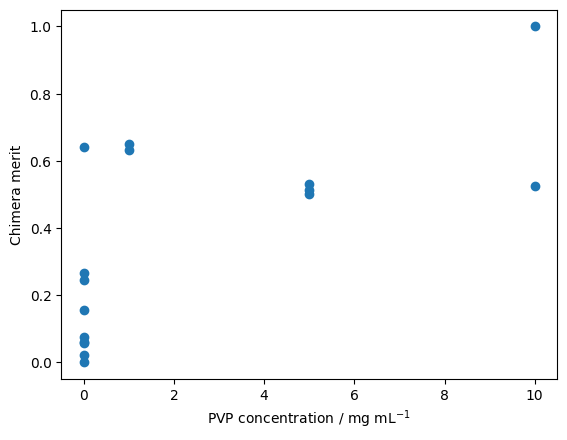

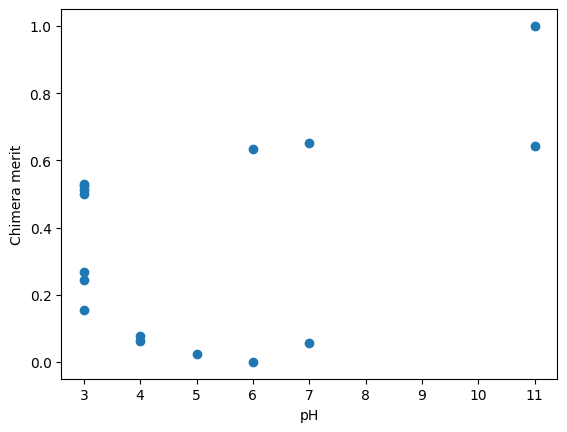

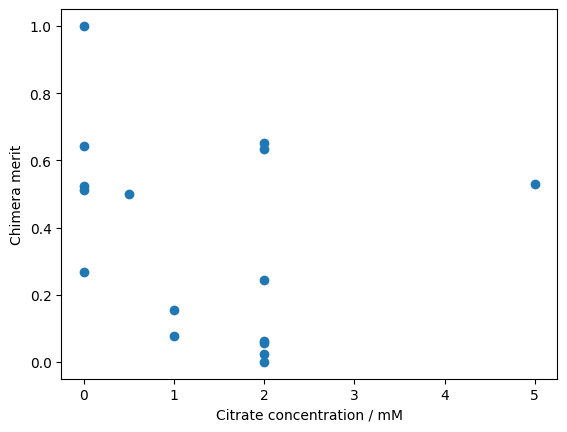

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df_model["PVP_mg_ml"], df_model["chimera_merit"])
plt.xlabel("PVP concentration / mg mL$^{-1}$")
plt.ylabel("Chimera merit")
plt.show()

plt.scatter(df_model["pH"], df_model["chimera_merit"])
plt.xlabel("pH")
plt.ylabel("Chimera merit")
plt.show()

plt.scatter(df_model["Citrate_mM"], df_model["chimera_merit"])
plt.xlabel("Citrate concentration / mM")
plt.ylabel("Chimera merit")
plt.show()

process 2: surrogate model

In [10]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

y = df_model["chimera_merit"].values

kernel = ConstantKernel(1.0) * Matern(nu=2.5) + WhiteKernel()

gp = make_pipeline(
    StandardScaler(),
    GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=0)
)

gp.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gaussianprocessregressor',
                 GaussianProcessRegressor(kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1),
                                          normalize_y=True, random_state=0))])

In [11]:
from scipy.stats import norm

In [12]:
def expected_improvement_minimization(X_candidates, gp, y_observed, xi=0.01):
    """
    Expected Improvement for minimization.

    X_candidates: candidate experimental conditions
    gp: trained Gaussian Process pipeline
    y_observed: observed Chimera merit values
    xi: exploration parameter
    """

    mu, sigma = gp.predict(X_candidates, return_std=True)

    y_best = np.min(y_observed)

    improvement = y_best - mu - xi

    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

    ei[sigma == 0.0] = 0.0

    return ei, mu, sigma

In [14]:
candidate_data = []

for pvp in [ 0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1, 5, 10, 20, 30, 40, 50]:
    for citrate in [0, 0.1, 0.2,0.3,0.4, 0.5,0.6,0.7,0.8,0.9, 1, 2]:
        for ph in [1,2,3,4, 5,6, 7,8,9, 10, 11]:
            candidate_data.append([
                1,       # HAuCl4_mM
                pvp,     # PVP_mg_ml
                20,      # AA_mM
                citrate, # Citrate_mM
                ph,      # pH
                30,      # Au_flow_rate
                30       # reducing_agent_flow_rate_mL_h
            ])

X_candidates = np.array(candidate_data)
candidate_df = pd.DataFrame(X_candidates, columns=input_cols)

In [15]:
ei, mu, sigma = expected_improvement_minimization(
    X_candidates,
    gp,
    y,
    xi=0.01
)

candidate_df["predicted_merit_mu"] = mu
candidate_df["uncertainty_sigma"] = sigma
candidate_df["EI"] = ei

candidate_df.sort_values("EI", ascending=False).head(10)

,HAuCl4_mM,PVP_mg_ml,AA_mM,Citrate_mM,pH,Au_flow_rate,reducing_agent_flow_rate_mL_h,predicted_merit_mu,uncertainty_sigma,EI
121,1.0,0.0,20.0,2.0,1.0,30.0,30.0,0.176872,0.241321,0.030342
2233,1.0,50.0,20.0,2.0,1.0,30.0,30.0,0.369423,0.373643,0.030224
2112,1.0,50.0,20.0,0.0,1.0,30.0,30.0,0.369442,0.373642,0.030221
2123,1.0,50.0,20.0,0.1,1.0,30.0,30.0,0.369447,0.373642,0.030220
2134,1.0,50.0,20.0,0.2,1.0,30.0,30.0,0.369451,0.373642,0.030220
2145,1.0,50.0,20.0,0.3,1.0,30.0,30.0,0.369454,0.373642,0.030219
2156,1.0,50.0,20.0,0.4,1.0,30.0,30.0,0.369456,0.373642,0.030219
2167,1.0,50.0,20.0,0.5,1.0,30.0,30.0,0.369459,0.373642,0.030218
2178,1.0,50.0,20.0,0.6,1.0,30.0,30.0,0.369460,0.373642,0.030218
2222,1.0,50.0,20.0,1.0,1.0,30.0,30.0,0.369461,0.373642,0.030218
